# Calculus — Computational Examples

Interactive demonstrations of core calculus concepts for mathematical modeling:
1. Numerical differentiation vs. analytical
2. Plotting functions and their derivatives
3. Numerical integration (trapezoidal, Simpson's rule)
4. Taylor series approximation visualization
5. Gradient visualization for 2D functions

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, misc

rng = np.random.default_rng(seed=42)

# Plot style
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

/tmp/ipykernel_12419/2499371845.py:6: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import integrate, misc


---
## 1. Numerical Differentiation vs. Analytical

The derivative $f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$ can be approximated numerically:

- **Forward difference:** $f'(x) \approx \frac{f(x+h) - f(x)}{h}$ — error $O(h)$
- **Central difference:** $f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$ — error $O(h^2)$

Let's test with $f(x) = \sin(x)$, whose analytical derivative is $f'(x) = \cos(x)$.

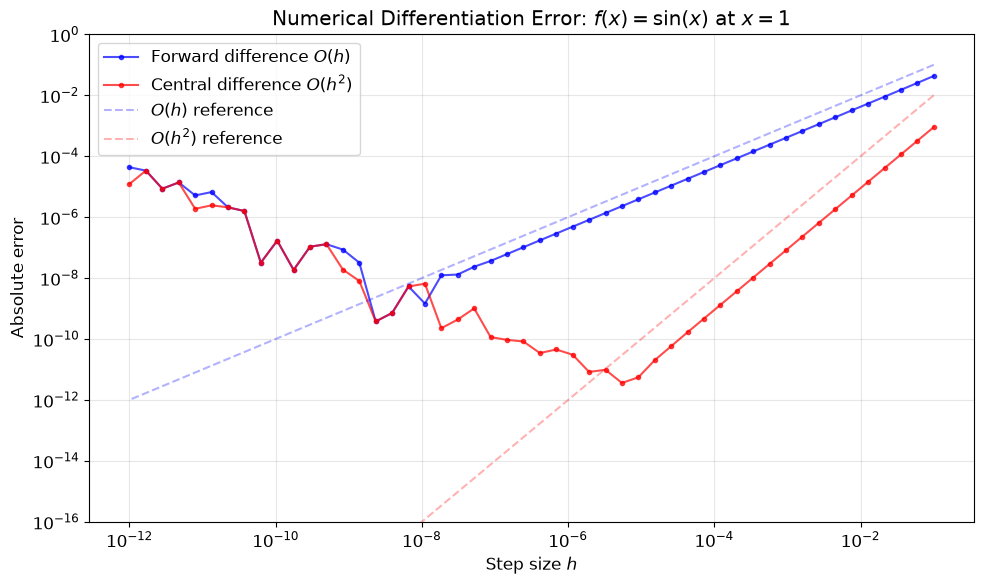

Exact derivative cos(1) = 0.5403023059
Forward (h=1e-5):  0.5402980985, error = 4.21e-06
Central (h=1e-5):  0.5403023059, error = 1.11e-11


In [2]:
def forward_diff(f, x, h):
    """Forward difference approximation of f'(x)."""
    return (f(x + h) - f(x)) / h

def central_diff(f, x, h):
    """Central difference approximation of f'(x)."""
    return (f(x + h) - f(x - h)) / (2 * h)

# Test at x = 1
x0 = 1.0
exact = np.cos(x0)

h_values = np.logspace(-1, -12, 50)
forward_errors = [abs(forward_diff(np.sin, x0, h) - exact) for h in h_values]
central_errors = [abs(central_diff(np.sin, x0, h) - exact) for h in h_values]

fig, ax = plt.subplots()
ax.loglog(h_values, forward_errors, 'b.-', label='Forward difference $O(h)$', alpha=0.7)
ax.loglog(h_values, central_errors, 'r.-', label='Central difference $O(h^2)$', alpha=0.7)
ax.loglog(h_values, h_values, 'b--', alpha=0.3, label='$O(h)$ reference')
ax.loglog(h_values, h_values**2, 'r--', alpha=0.3, label='$O(h^2)$ reference')
ax.set_xlabel('Step size $h$')
ax.set_ylabel('Absolute error')
ax.set_title('Numerical Differentiation Error: $f(x) = \\sin(x)$ at $x = 1$')
ax.legend()
ax.set_ylim(1e-16, 1)
plt.tight_layout()
plt.show()

print(f"Exact derivative cos(1) = {exact:.10f}")
print(f"Forward (h=1e-5):  {forward_diff(np.sin, x0, 1e-5):.10f}, error = {abs(forward_diff(np.sin, x0, 1e-5) - exact):.2e}")
print(f"Central (h=1e-5):  {central_diff(np.sin, x0, 1e-5):.10f}, error = {abs(central_diff(np.sin, x0, 1e-5) - exact):.2e}")

**Observation:** The central difference has error $O(h^2)$, much better than the forward difference's $O(h)$. But for very small $h$ ($< 10^{-8}$), **round-off error** from floating-point arithmetic dominates. The optimal $h$ is around $10^{-5}$ for forward and $10^{-5}$ to $10^{-6}$ for central differences.

---
## 2. Plotting Functions and Their Derivatives

Visualizing $f(x)$ alongside $f'(x)$ builds intuition for the relationship between a function and its rate of change.

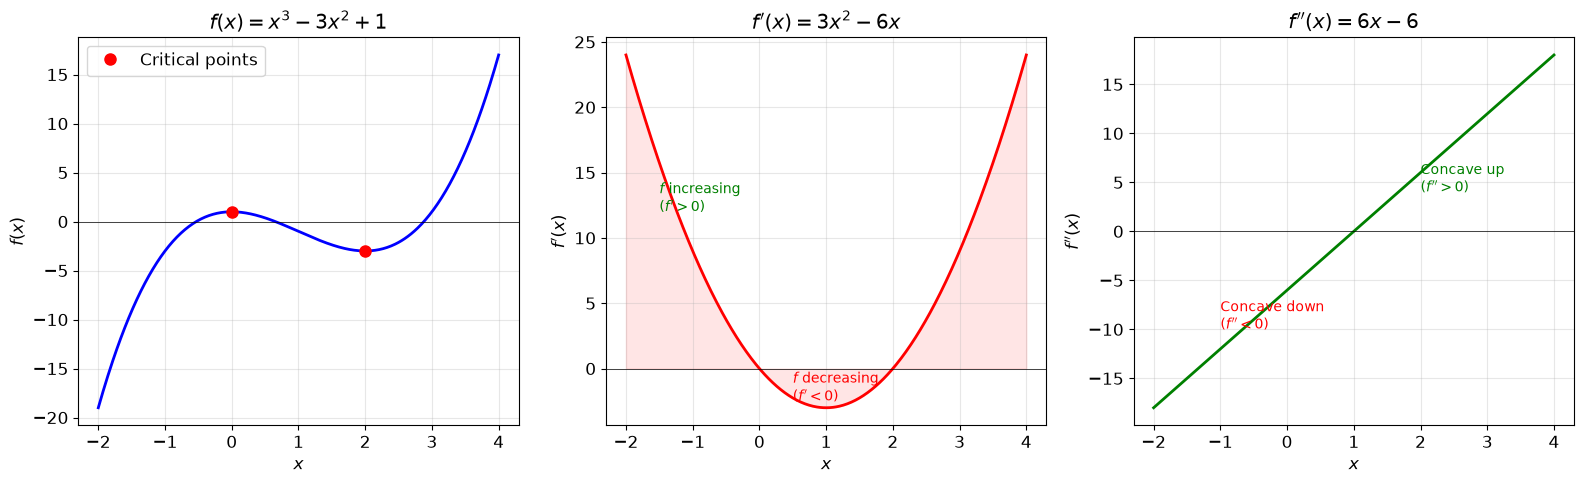

In [3]:
x = np.linspace(-2, 4, 500)

# Example 1: Polynomial f(x) = x³ - 3x² + 1
f1 = x**3 - 3*x**2 + 1
f1_prime = 3*x**2 - 6*x
f1_double_prime = 6*x - 6

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# f(x)
axes[0].plot(x, f1, 'b-', linewidth=2)
axes[0].axhline(y=0, color='k', linewidth=0.5)
axes[0].set_title('$f(x) = x^3 - 3x^2 + 1$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$f(x)$')

# Critical points: f'(x) = 0 at x=0, x=2
axes[0].plot([0, 2], [1, -3], 'ro', markersize=8, label='Critical points')
axes[0].legend()

# f'(x)
axes[1].plot(x, f1_prime, 'r-', linewidth=2)
axes[1].axhline(y=0, color='k', linewidth=0.5)
axes[1].fill_between(x, f1_prime, alpha=0.1, color='r')
axes[1].set_title("$f'(x) = 3x^2 - 6x$")
axes[1].set_xlabel('$x$')
axes[1].set_ylabel("$f'(x)$")

# Annotate: f' > 0 means f increasing
axes[1].annotate('$f$ increasing\n($f\' > 0$)', xy=(-1.5, 12), fontsize=10, color='green')
axes[1].annotate('$f$ decreasing\n($f\' < 0$)', xy=(0.5, -2.5), fontsize=10, color='red')

# f''(x)
axes[2].plot(x, f1_double_prime, 'g-', linewidth=2)
axes[2].axhline(y=0, color='k', linewidth=0.5)
axes[2].set_title("$f''(x) = 6x - 6$")
axes[2].set_xlabel('$x$')
axes[2].set_ylabel("$f''(x)$")
axes[2].annotate('Concave up\n($f\'\' > 0$)', xy=(2, 4), fontsize=10, color='green')
axes[2].annotate('Concave down\n($f\'\' < 0$)', xy=(-1, -10), fontsize=10, color='red')

plt.tight_layout()
plt.show()

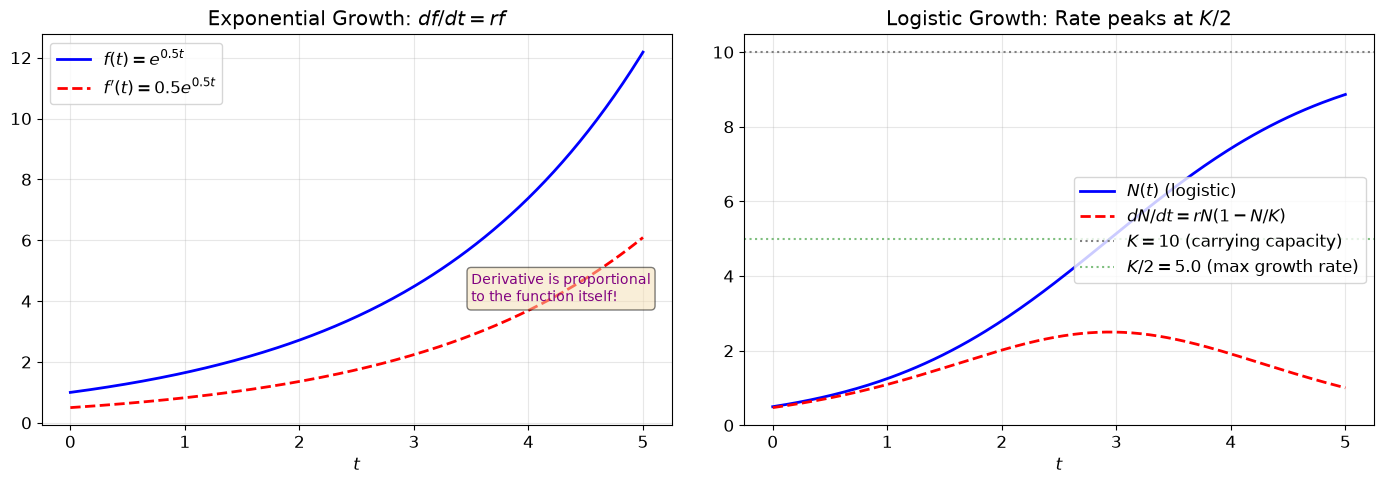

In [4]:
# Example 2: Exponential growth/decay — the fundamental modeling functions
t = np.linspace(0, 5, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exponential growth: f(t) = e^(0.5t)
r = 0.5
growth = np.exp(r * t)
growth_rate = r * np.exp(r * t)  # df/dt = r * e^(rt) = r * f

axes[0].plot(t, growth, 'b-', linewidth=2, label=f'$f(t) = e^{{{r}t}}$')
axes[0].plot(t, growth_rate, 'r--', linewidth=2, label=f"$f'(t) = {r}e^{{{r}t}}$")
axes[0].set_title('Exponential Growth: $df/dt = rf$')
axes[0].set_xlabel('$t$')
axes[0].legend()
axes[0].annotate('Derivative is proportional\nto the function itself!',
                 xy=(3.5, 4), fontsize=10, color='purple',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Logistic growth
K = 10
r_log = 1.0
N0 = 0.5
logistic = K / (1 + ((K - N0) / N0) * np.exp(-r_log * t))
logistic_rate = r_log * logistic * (1 - logistic / K)

axes[1].plot(t, logistic, 'b-', linewidth=2, label='$N(t)$ (logistic)')
axes[1].plot(t, logistic_rate, 'r--', linewidth=2, label="$dN/dt = rN(1 - N/K)$")
axes[1].axhline(y=K, color='gray', linestyle=':', label=f'$K = {K}$ (carrying capacity)')
axes[1].axhline(y=K/2, color='green', linestyle=':', alpha=0.5, label=f'$K/2 = {K/2}$ (max growth rate)')
axes[1].set_title('Logistic Growth: Rate peaks at $K/2$')
axes[1].set_xlabel('$t$')
axes[1].legend(loc='right')

plt.tight_layout()
plt.show()

---
## 3. Numerical Integration

Numerical integration approximates $\int_a^b f(x)\,dx$ when no closed-form antiderivative is available.

### Methods:
- **Trapezoidal rule:** Approximate $f$ with piecewise linear segments. Error $O(h^2)$.
- **Simpson's rule:** Approximate $f$ with piecewise quadratics. Error $O(h^4)$.

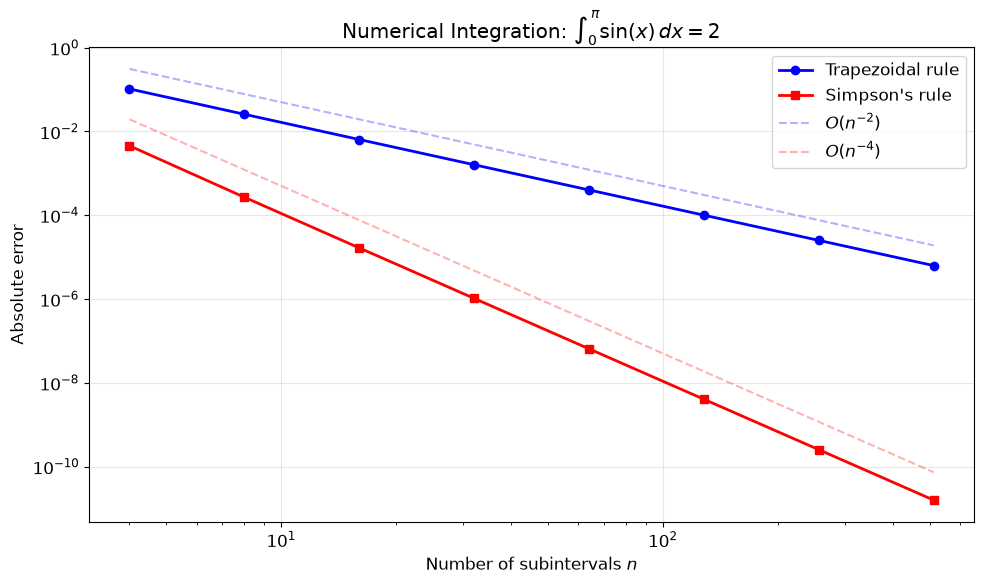

     n     Trapezoidal        Error        Simpsons        Error
-----------------------------------------------------------------
     4    1.8961188979     1.04e-01    2.0045597550     4.56e-03
     8    1.9742316019     2.58e-02    2.0002691699     2.69e-04
    16    1.9935703438     6.43e-03    2.0000165910     1.66e-05
    32    1.9983933610     1.61e-03    2.0000010334     1.03e-06
    64    1.9995983886     4.02e-04    2.0000000645     6.45e-08
   128    1.9998996002     1.00e-04    2.0000000040     4.03e-09
   256    1.9999749002     2.51e-05    2.0000000003     2.52e-10
   512    1.9999937251     6.27e-06    2.0000000000     1.57e-11


In [5]:
def trapezoidal(f, a, b, n):
    """Trapezoidal rule with n subintervals."""
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return h * (0.5 * y[0] + np.sum(y[1:-1]) + 0.5 * y[-1])

def simpsons(f, a, b, n):
    """Simpson's rule with n subintervals (n must be even)."""
    assert n % 2 == 0, "n must be even for Simpson's rule"
    x = np.linspace(a, b, n + 1)
    y = f(x)
    h = (b - a) / n
    return (h / 3) * (y[0] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2]) + y[-1])

# Test: ∫₀^π sin(x) dx = 2 (exact)
f = np.sin
a, b = 0, np.pi
exact_integral = 2.0

n_values = [4, 8, 16, 32, 64, 128, 256, 512]
trap_errors = [abs(trapezoidal(f, a, b, n) - exact_integral) for n in n_values]
simp_errors = [abs(simpsons(f, a, b, n) - exact_integral) for n in n_values]

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(n_values, trap_errors, 'bo-', linewidth=2, label='Trapezoidal rule')
ax.loglog(n_values, simp_errors, 'rs-', linewidth=2, label="Simpson's rule")

# Reference slopes
n_ref = np.array(n_values, dtype=float)
ax.loglog(n_ref, 5 * n_ref**(-2), 'b--', alpha=0.3, label='$O(n^{-2})$')
ax.loglog(n_ref, 5 * n_ref**(-4), 'r--', alpha=0.3, label='$O(n^{-4})$')

ax.set_xlabel('Number of subintervals $n$')
ax.set_ylabel('Absolute error')
ax.set_title('Numerical Integration: $\\int_0^{\\pi} \\sin(x)\\,dx = 2$')
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'n':>6} {'Trapezoidal':>15} {'Error':>12} {'Simpsons':>15} {'Error':>12}")
print("-" * 65)
for n, te, se in zip(n_values, trap_errors, simp_errors):
    print(f"{n:>6} {trapezoidal(f, a, b, n):>15.10f} {te:>12.2e} {simpsons(f, a, b, n):>15.10f} {se:>12.2e}")

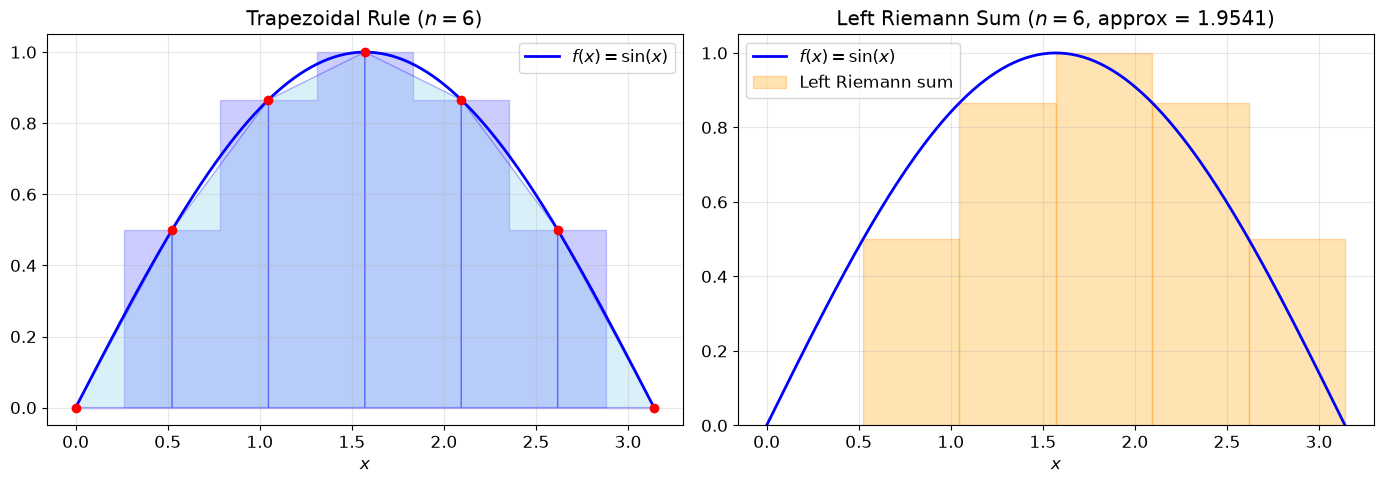

In [6]:
# Visualize what the trapezoidal rule actually does
n_demo = 6
x_fine = np.linspace(0, np.pi, 200)
x_trap = np.linspace(0, np.pi, n_demo + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trapezoidal rule visualization
axes[0].plot(x_fine, np.sin(x_fine), 'b-', linewidth=2, label='$f(x) = \\sin(x)$')
axes[0].fill_between(x_trap, 0, np.sin(x_trap), alpha=0.2, color='blue', step='mid')
for i in range(n_demo):
    axes[0].fill([x_trap[i], x_trap[i], x_trap[i+1], x_trap[i+1]],
                 [0, np.sin(x_trap[i]), np.sin(x_trap[i+1]), 0],
                 alpha=0.3, color='skyblue', edgecolor='blue')
axes[0].plot(x_trap, np.sin(x_trap), 'ro', markersize=6)
axes[0].set_title(f'Trapezoidal Rule ($n = {n_demo}$)')
axes[0].set_xlabel('$x$')
axes[0].legend()

# Riemann sum visualization (left endpoint)
h = np.pi / n_demo
x_left = np.linspace(0, np.pi - h, n_demo)
axes[1].plot(x_fine, np.sin(x_fine), 'b-', linewidth=2, label='$f(x) = \\sin(x)$')
axes[1].bar(x_left, np.sin(x_left), width=h, alpha=0.3, align='edge',
            color='orange', edgecolor='darkorange', label='Left Riemann sum')
riemann_approx = h * np.sum(np.sin(x_left))
axes[1].set_title(f'Left Riemann Sum ($n = {n_demo}$, approx = {riemann_approx:.4f})')
axes[1].set_xlabel('$x$')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 4. Taylor Series Approximation

The Taylor series of $f(x)$ about $a$ is:

$$f(x) \approx \sum_{k=0}^{n} \frac{f^{(k)}(a)}{k!}(x - a)^k$$

Let's visualize how successive Taylor polynomials approximate $e^x$, $\sin(x)$, and $\ln(1+x)$.

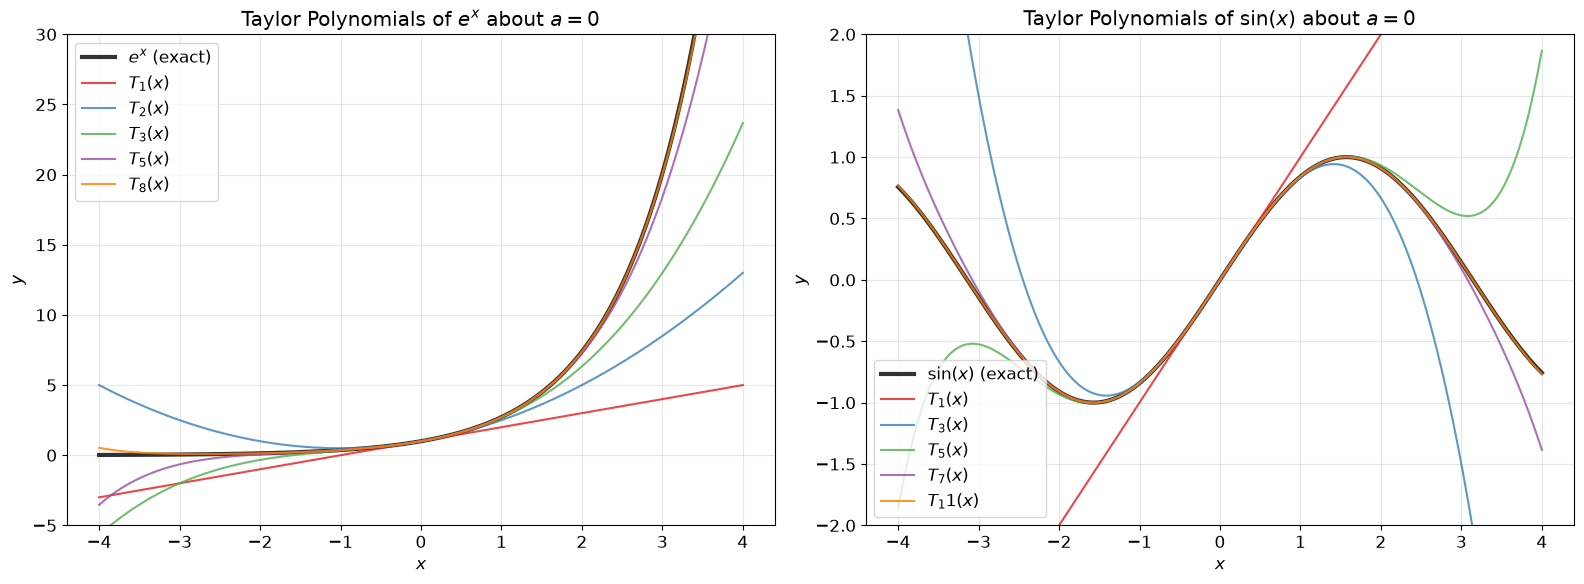

In [7]:
from math import factorial

def taylor_exp(x, n, a=0):
    """Taylor polynomial of e^x about a, degree n."""
    return sum(np.exp(a) * (x - a)**k / factorial(k) for k in range(n + 1))

def taylor_sin(x, n, a=0):
    """Taylor polynomial of sin(x) about a=0, degree n."""
    result = np.zeros_like(x, dtype=float)
    for k in range(n + 1):
        if k % 2 == 1:  # only odd terms
            sign = (-1)**((k - 1) // 2)
            result += sign * x**k / factorial(k)
    return result

x = np.linspace(-4, 4, 500)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Taylor approximation of e^x
axes[0].plot(x, np.exp(x), 'k-', linewidth=3, label='$e^x$ (exact)', alpha=0.8)
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
for i, n in enumerate([1, 2, 3, 5, 8]):
    y_approx = taylor_exp(x, n)
    axes[0].plot(x, y_approx, color=colors[i], linewidth=1.5,
                label=f'$T_{n}(x)$', alpha=0.8)

axes[0].set_ylim(-5, 30)
axes[0].set_title('Taylor Polynomials of $e^x$ about $a = 0$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$y$')
axes[0].legend(loc='upper left')

# Taylor approximation of sin(x)
axes[1].plot(x, np.sin(x), 'k-', linewidth=3, label='$\\sin(x)$ (exact)', alpha=0.8)
for i, n in enumerate([1, 3, 5, 7, 11]):
    y_approx = taylor_sin(x, n)
    axes[1].plot(x, y_approx, color=colors[i], linewidth=1.5,
                label=f'$T_{n}(x)$', alpha=0.8)

axes[1].set_ylim(-2, 2)
axes[1].set_title('Taylor Polynomials of $\\sin(x)$ about $a = 0$')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$y$')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()

In [8]:
# Quantify the Taylor approximation error
x_test = 1.0  # Approximate e^1 = e ≈ 2.71828...
exact_val = np.exp(x_test)

print(f"Taylor approximation of e^{x_test} = {exact_val:.10f}")
print(f"{'Degree n':>10} {'T_n(x)':>15} {'Error':>12} {'Error bound':>15}")
print("-" * 55)
for n in range(1, 12):
    approx = sum(x_test**k / factorial(k) for k in range(n + 1))
    error = abs(approx - exact_val)
    # Taylor remainder bound: |R_n| <= M * |x-a|^(n+1) / (n+1)! where M = max|f^(n+1)| on [0, x]
    bound = np.exp(x_test) * abs(x_test)**(n + 1) / factorial(n + 1)
    print(f"{n:>10} {approx:>15.10f} {error:>12.2e} {bound:>15.2e}")

Taylor approximation of e^1.0 = 2.7182818285
  Degree n          T_n(x)        Error     Error bound
-------------------------------------------------------
         1    2.0000000000     7.18e-01        1.36e+00
         2    2.5000000000     2.18e-01        4.53e-01
         3    2.6666666667     5.16e-02        1.13e-01
         4    2.7083333333     9.95e-03        2.27e-02
         5    2.7166666667     1.62e-03        3.78e-03
         6    2.7180555556     2.26e-04        5.39e-04
         7    2.7182539683     2.79e-05        6.74e-05
         8    2.7182787698     3.06e-06        7.49e-06
         9    2.7182815256     3.03e-07        7.49e-07
        10    2.7182818011     2.73e-08        6.81e-08
        11    2.7182818262     2.26e-09        5.67e-09


**Key takeaway:** The Taylor series converges rapidly near the expansion point. For $e^1$, just 10 terms give 10 digits of accuracy. This is why linearization ($n=1$) works well for small perturbations from equilibrium.

---
## 5. Gradient Visualization for 2D Functions

The gradient $\nabla f(x, y) = \left(\frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}\right)$ points in the direction of steepest ascent.

This is the foundation of **gradient descent** for optimization.

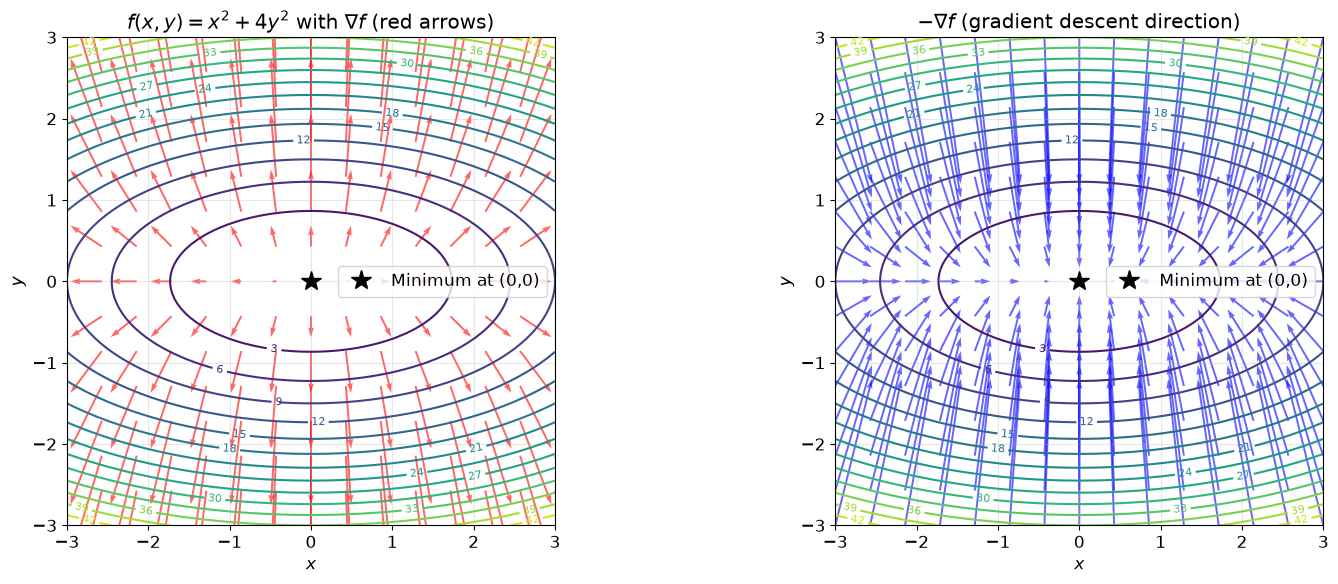

In [9]:
# Example 1: Quadratic f(x,y) = x² + 4y² (elliptic paraboloid)
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + 4*Y**2

# Gradient: ∇f = (2x, 8y)
# Use a coarser grid for quiver plot
x_q = np.linspace(-3, 3, 15)
y_q = np.linspace(-3, 3, 15)
Xq, Yq = np.meshgrid(x_q, y_q)
Uq = 2 * Xq  # ∂f/∂x
Vq = 8 * Yq  # ∂f/∂y

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contour plot with gradient vectors
cs = axes[0].contour(X, Y, Z, levels=15, cmap='viridis')
axes[0].clabel(cs, inline=True, fontsize=8)
axes[0].quiver(Xq, Yq, Uq, Vq, color='red', alpha=0.6, scale=80)
axes[0].set_title('$f(x,y) = x^2 + 4y^2$ with $\\nabla f$ (red arrows)')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$y$')
axes[0].set_aspect('equal')
axes[0].plot(0, 0, 'k*', markersize=15, label='Minimum at (0,0)')
axes[0].legend()

# Negative gradient (gradient descent direction)
cs2 = axes[1].contour(X, Y, Z, levels=15, cmap='viridis')
axes[1].clabel(cs2, inline=True, fontsize=8)
axes[1].quiver(Xq, Yq, -Uq, -Vq, color='blue', alpha=0.6, scale=80)
axes[1].set_title('$-\\nabla f$ (gradient descent direction)')
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$y$')
axes[1].set_aspect('equal')
axes[1].plot(0, 0, 'k*', markersize=15, label='Minimum at (0,0)')
axes[1].legend()

plt.tight_layout()
plt.show()

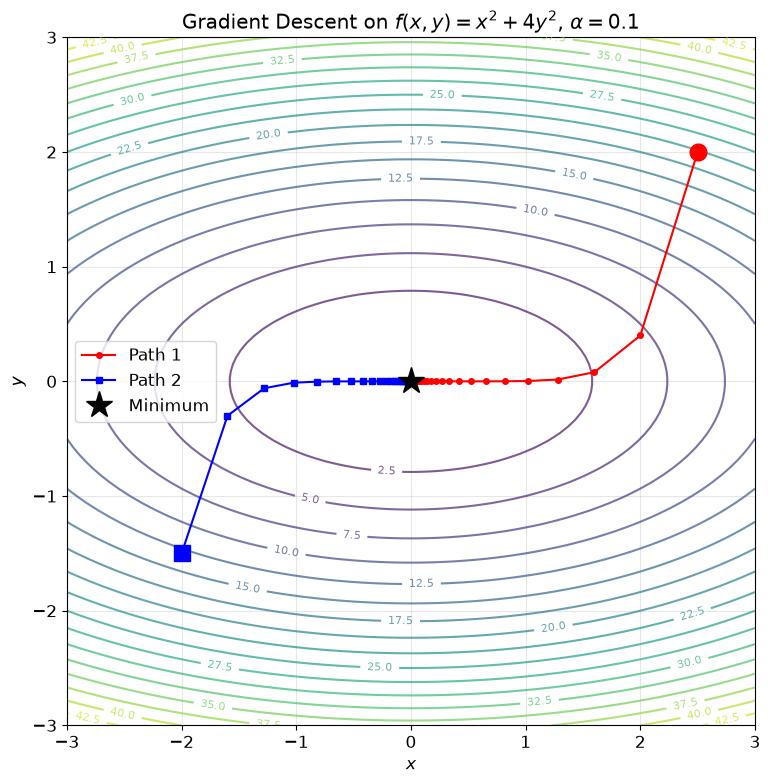

Path 1: 51 steps, f decreased from 22.2500 to 1.27e-09
Path 2: 51 steps, f decreased from 13.0000 to 8.15e-10


In [10]:
# Gradient descent simulation on f(x,y) = x² + 4y²
def gradient_descent_2d(f, grad_f, x0, alpha=0.1, max_iter=50, tol=1e-8):
    """Simple gradient descent with fixed step size."""
    path = [x0.copy()]
    x = x0.copy()
    for i in range(max_iter):
        g = grad_f(x)
        x = x - alpha * g
        path.append(x.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(path)

f_quad = lambda p: p[0]**2 + 4*p[1]**2
grad_quad = lambda p: np.array([2*p[0], 8*p[1]])

# Run gradient descent from two starting points
path1 = gradient_descent_2d(f_quad, grad_quad, np.array([2.5, 2.0]), alpha=0.1)
path2 = gradient_descent_2d(f_quad, grad_quad, np.array([-2.0, -1.5]), alpha=0.1)

fig, ax = plt.subplots(figsize=(8, 8))
cs = ax.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.7)
ax.clabel(cs, inline=True, fontsize=8)

ax.plot(path1[:, 0], path1[:, 1], 'ro-', markersize=4, linewidth=1.5, label='Path 1')
ax.plot(path2[:, 0], path2[:, 1], 'bs-', markersize=4, linewidth=1.5, label='Path 2')
ax.plot(path1[0, 0], path1[0, 1], 'ro', markersize=12)
ax.plot(path2[0, 0], path2[0, 1], 'bs', markersize=12)
ax.plot(0, 0, 'k*', markersize=20, label='Minimum')

ax.set_title('Gradient Descent on $f(x,y) = x^2 + 4y^2$, $\\alpha = 0.1$')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

# Show convergence
f_values1 = [f_quad(p) for p in path1]
print(f"Path 1: {len(path1)} steps, f decreased from {f_values1[0]:.4f} to {f_values1[-1]:.2e}")
f_values2 = [f_quad(p) for p in path2]
print(f"Path 2: {len(path2)} steps, f decreased from {f_values2[0]:.4f} to {f_values2[-1]:.2e}")

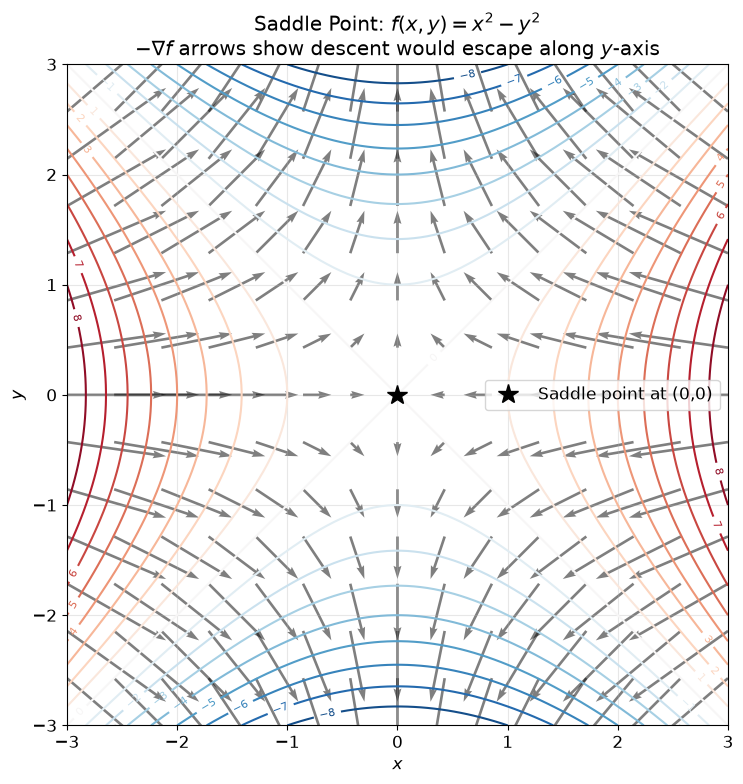

At the saddle point (0,0):
  Hessian H = [[2, 0], [0, -2]]
  Eigenvalues: 2 (positive) and -2 (negative)
  → Indefinite Hessian → saddle point (not a min or max)


In [11]:
# Example 2: Non-convex function with saddle point
# f(x,y) = x² - y² (hyperbolic paraboloid / saddle)
Z_saddle = X**2 - Y**2

# Gradient: ∇f = (2x, -2y)
Uq_s = 2 * Xq
Vq_s = -2 * Yq

fig, ax = plt.subplots(figsize=(8, 8))
cs = ax.contour(X, Y, Z_saddle, levels=20, cmap='RdBu_r')
ax.clabel(cs, inline=True, fontsize=8)
ax.quiver(Xq, Yq, -Uq_s, -Vq_s, color='black', alpha=0.5, scale=40)
ax.set_title('Saddle Point: $f(x,y) = x^2 - y^2$\n$-\\nabla f$ arrows show descent would escape along $y$-axis')
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_aspect('equal')
ax.plot(0, 0, 'k*', markersize=15, label='Saddle point at (0,0)')
ax.legend()
plt.tight_layout()
plt.show()

print("At the saddle point (0,0):")
print("  Hessian H = [[2, 0], [0, -2]]")
print("  Eigenvalues: 2 (positive) and -2 (negative)")
print("  → Indefinite Hessian → saddle point (not a min or max)")

---
## Summary

| Concept | Numerical Tool | Key Insight |
|---|---|---|
| Numerical derivative | Forward/central differences | Central differences are $O(h^2)$, but roundoff limits optimal $h$ |
| Function + derivative plots | matplotlib | $f' = 0$ at critical points; $f'' > 0$ means concave up |
| Numerical integration | Trapezoidal, Simpson's | Simpson's ($O(h^4)$) is far more accurate than trapezoidal ($O(h^2)$) |
| Taylor series | Polynomial approximation | Higher degree = wider range of validity; linearization = degree 1 |
| Gradient | Quiver + contour plots | $\nabla f$ points uphill; $-\nabla f$ for descent; saddle points are neither min nor max |